In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
import geopandas as gpd
import numpy as np
from cmdstanpy import CmdStanModel
from sklearn.preprocessing import StandardScaler
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering
import itertools
import os
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')



In [ ]:
# just to run on colab: DO NOT RUN IF YOUR PC IS NOT SHIT AS MINE
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [2]:
df = gpd.read_file('../data/updated_data.geojson')

In [3]:
y = df["fem_empl_rate"].to_numpy()
y = y / 100
y_star = np.log(y / (1 - y))

selected_covariates = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
X = df[selected_covariates].to_numpy()
X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

offset = df["mal_empl_rate"].to_numpy()
offset = offset / 100
offset_star = np.log(offset / (1 - offset))

N = 107 
P = len(selected_covariates) 
K = 1 

In [4]:
df = df.reset_index(drop=True)

n = len(df)
node1 = []
node2 = []
num_neighbors = np.zeros(n, dtype=int)

sindex = df.sindex  # spatial index

for i, geom in enumerate(df.geometry):
    # candidates using bounding boxes
    possible_matches = list(sindex.intersection(geom.bounds))

    for j in possible_matches:
        if j <= i:
            continue
        if geom.touches(df.geometry[j]):
            node1.append(i + 1)   # Stan is 1-based
            node2.append(j + 1)

            num_neighbors[i] += 1
            num_neighbors[j] += 1

node1 = np.asarray(node1, dtype=int)
node2 = np.asarray(node2, dtype=int)

W = np.zeros((n, n), dtype=int)

for i, j in zip(node1 - 1, node2 - 1):
    W[i, j] = 1
    W[j, i] = 1

## Label Assignment

In [5]:
mix_model = """
functions {
  real car_leroux_lpdf(
    vector phi,
    real tau2,
    real rho,
    matrix W,
    vector D,
    vector lambda,
    int N
  ) {
    vector[N] Dphi;
    vector[N] Wphi;
    vector[N] det_terms;
    real quad;

    Dphi = D .* phi;        // D * phi
    Wphi = W * phi;         // W * phi

    for (i in 1 : N) {
      det_terms[i] = log(rho * lambda[i] + (1 - rho)); // eigenvalues of D-W
    }

    quad = rho * (dot_product(phi, Dphi) - dot_product(phi, Wphi)) + (1 - rho) * dot_product(phi, phi);

    return 0.5 * (
      N * log(tau2)
      + sum(det_terms)  
      - tau2 * quad
    );
  }
}

data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;           
  matrix<lower=0, upper=1>[N, N] W;       
}

transformed data {
  vector[N] D;            // diagonal entries of D
  vector[N] lambda;       // eigenvalues of D-W

  for (i in 1:N)
    D[i] = sum(W[i]);

  lambda = eigenvalues_sym(diag_matrix(D) - W);      // eigenvalues
}

parameters {
  simplex[K] pi;           
  vector[K] alpha;         
  vector[P] beta; 
  real<lower=1e-6> sigma; 
  real<lower=1e-6> tau2;                  // CAR precision
  vector[N] phi_raw;                        // Spatial random effects
  real<lower=0, upper=0.95> rho;      // Leroux dependence parameter
}

transformed parameters {
  vector[N] phi;
  phi = phi_raw - mean(phi_raw);
}


model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K)); 


  tau2  ~ gamma(2, 1);
  rho   ~ beta(1,1);
  sigma ~ inv_gamma(2, 1);
  
  for (k in 1:K) {
    alpha[k] ~ normal(0, 1);
  }

  for (j in 1:P) {
    beta[j] ~ normal(0, 1);
  }

  phi_raw ~ car_leroux(tau2, rho, W, D, lambda, N);

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta) + phi[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  array[N] int z;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      real mu_ik = alpha[k] + X_star[i] * beta + phi[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
    
  }
}

"""

In [6]:
with open("normal_mixture.stan", "w") as f:
    f.write(mix_model)

In [7]:
data = {
    "N": int(N),
    "P": int(P),
    "K": int(K),
    "y_star": y_star.astype(float),
    "X_star": X_star.astype(float),
    "W": W,
}


In [8]:
mix_stan = CmdStanModel(stan_file="normal_mixture.stan")

07:43:15 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture.exe
07:45:14 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture.exe


In [9]:
fit = mix_stan.sample(
    data=data,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.95,
    max_treedepth=12
)

07:45:15 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

07:45:29 - cmdstanpy - INFO - CmdStan done processing.
07:45:29 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'normal_mixture.stan', line 74, column 2 to column 22)
Consider re-running with show_console=True if the above output is unclear!


In [10]:
fit.column_names

('lp__',
 'accept_stat__',
 'stepsize__',
 'treedepth__',
 'n_leapfrog__',
 'divergent__',
 'energy__',
 'pi[1]',
 'alpha[1]',
 'beta[1]',
 'beta[2]',
 'beta[3]',
 'beta[4]',
 'beta[5]',
 'beta[6]',
 'beta[7]',
 'beta[8]',
 'beta[9]',
 'beta[10]',
 'sigma',
 'tau2',
 'phi_raw[1]',
 'phi_raw[2]',
 'phi_raw[3]',
 'phi_raw[4]',
 'phi_raw[5]',
 'phi_raw[6]',
 'phi_raw[7]',
 'phi_raw[8]',
 'phi_raw[9]',
 'phi_raw[10]',
 'phi_raw[11]',
 'phi_raw[12]',
 'phi_raw[13]',
 'phi_raw[14]',
 'phi_raw[15]',
 'phi_raw[16]',
 'phi_raw[17]',
 'phi_raw[18]',
 'phi_raw[19]',
 'phi_raw[20]',
 'phi_raw[21]',
 'phi_raw[22]',
 'phi_raw[23]',
 'phi_raw[24]',
 'phi_raw[25]',
 'phi_raw[26]',
 'phi_raw[27]',
 'phi_raw[28]',
 'phi_raw[29]',
 'phi_raw[30]',
 'phi_raw[31]',
 'phi_raw[32]',
 'phi_raw[33]',
 'phi_raw[34]',
 'phi_raw[35]',
 'phi_raw[36]',
 'phi_raw[37]',
 'phi_raw[38]',
 'phi_raw[39]',
 'phi_raw[40]',
 'phi_raw[41]',
 'phi_raw[42]',
 'phi_raw[43]',
 'phi_raw[44]',
 'phi_raw[45]',
 'phi_raw[46]',
 'phi_

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]   0.038  0.023  -0.006    0.079      0.001    0.000    1437.0   
beta[1]   0.012  0.029  -0.044    0.066      0.001    0.000    1238.0   
beta[2]   0.164  0.033   0.103    0.227      0.001    0.000    1124.0   
beta[3]   0.013  0.037  -0.059    0.080      0.001    0.001    1116.0   
beta[4]   0.012  0.040  -0.060    0.089      0.001    0.001     953.0   
...         ...    ...     ...      ...        ...      ...       ...   
phi[103]  0.127  0.077  -0.016    0.273      0.002    0.001    1840.0   
phi[104] -0.338  0.091  -0.504   -0.162      0.003    0.001     976.0   
phi[105] -0.113  0.078  -0.262    0.031      0.002    0.001    1621.0   
phi[106]  0.050  0.070  -0.081    0.184      0.001    0.001    2285.0   
rho       0.852  0.079   0.706    0.950      0.002    0.001    1138.0   

          ess_tail  r_hat  
beta[0]     2617.0    1.0  
beta[1]     2525.0    1.0  
beta[2]     2503.0    1.0  
beta[3]    

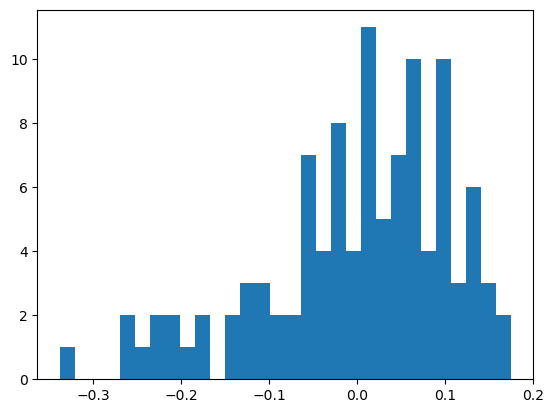

In [31]:
summary_beta_95 = az.summary(fit, var_names=["beta", "phi", "rho"])
print(summary_beta_95)
phi_mean = summary_beta_95.loc[summary_beta_95.index.str.startswith("phi"), "mean"].values
plt.hist(phi_mean, bins=30)

betas_mean = summary_beta_95.loc[summary_beta_95.index.str.startswith("beta"), "mean"].values

In [32]:
betas_mean

array([ 0.038,  0.012,  0.164,  0.013,  0.012, -0.038,  0.01 , -0.025,
       -0.085, -0.389])

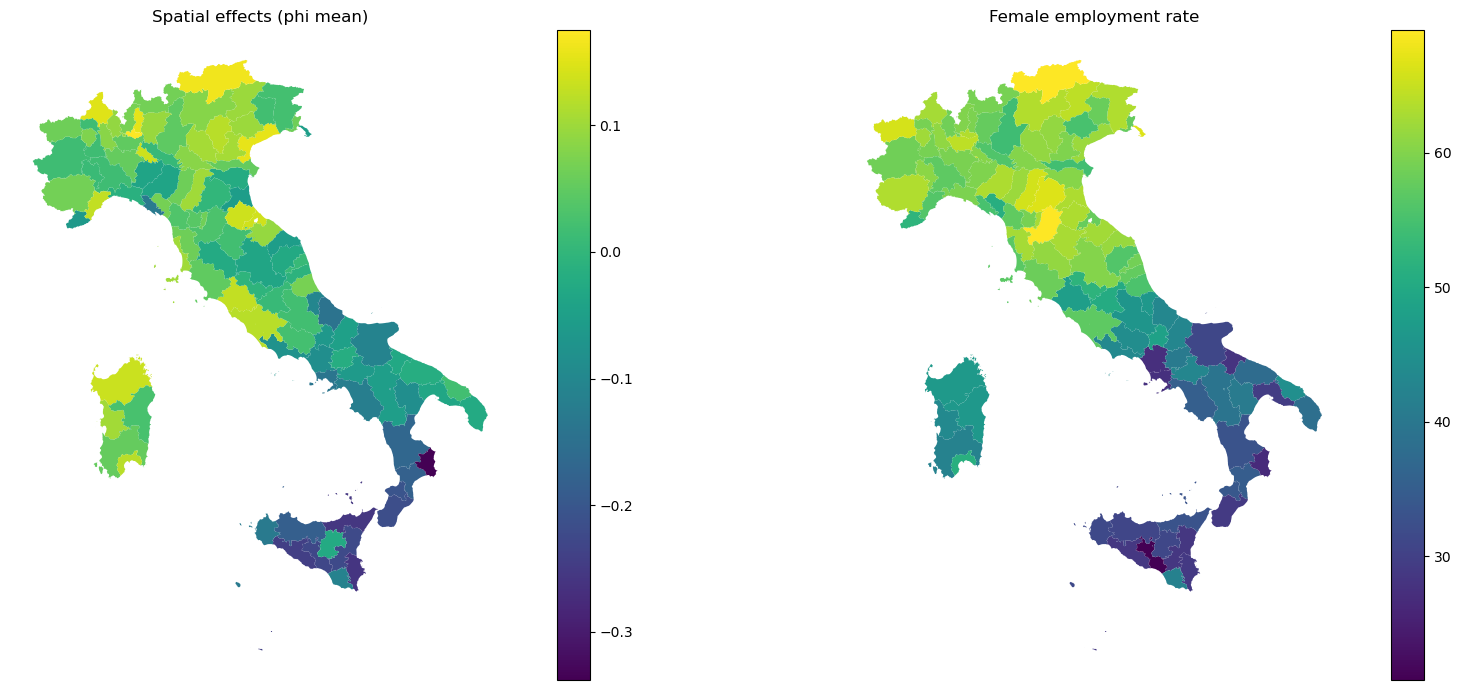

In [12]:
import geopandas as gpd

# gdf: GeoDataFrame with one row per observation/region
# must have a geometry column of polygons/multipolygons
gdf = gpd.read_file("../data/updated_data.geojson")
gdf["phi_mean"] = phi_mean

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

gdf.plot(column="phi_mean", categorical=False, legend=True, ax=ax1)
ax1.set_title("Spatial effects (phi mean)")
ax1.set_axis_off()

gdf.plot(column="fem_empl_rate", categorical=False, legend=True, ax=ax2)
ax2.set_title("Female employment rate")
ax2.set_axis_off()

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

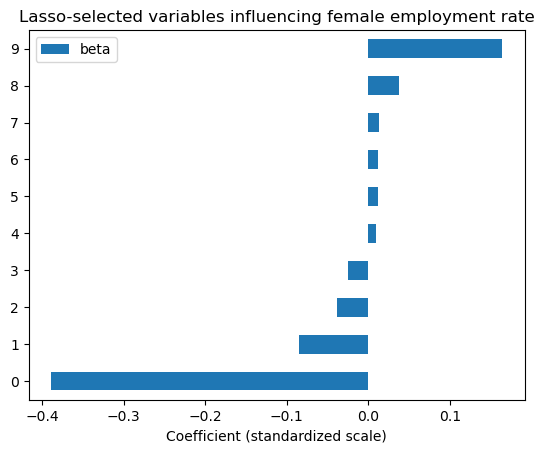

In [35]:
plt.figure(figsize=(8,6))
pd.DataFrame(betas_mean, columns=['beta']).sort_values(by='beta').plot(kind='barh')
plt.title('Lasso-selected variables influencing female employment rate')
plt.xlabel('Coefficient (standardized scale)')
plt.show()

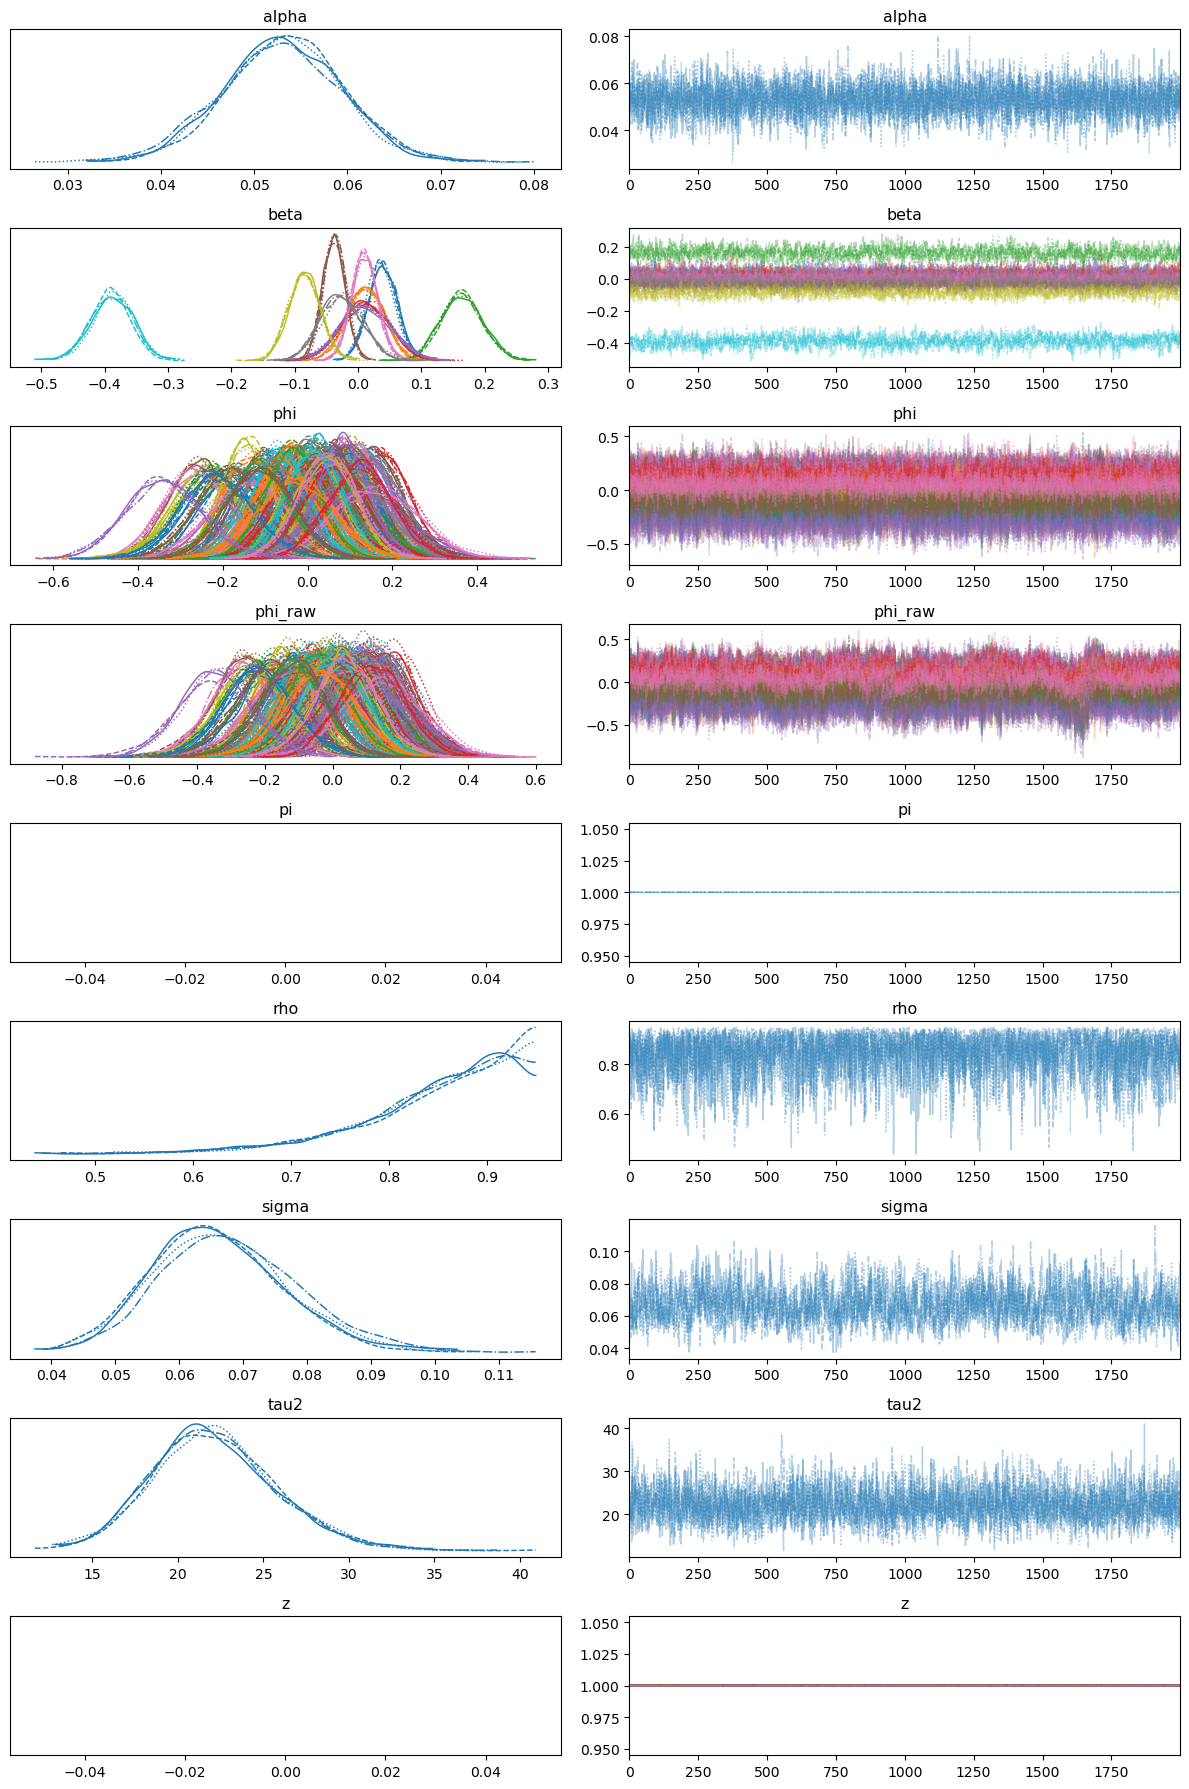

In [13]:
az.plot_trace(fit)
plt.tight_layout()

In [14]:
fit.stan_variables().keys()

dict_keys(['pi', 'alpha', 'beta', 'sigma', 'tau2', 'phi_raw', 'rho', 'phi', 'z'])

In [15]:
z_draws = fit.stan_variable("z")   # shape: (n_draws, N)

In [16]:
## For each draw:
# - compare couples of observations
# - if they are equal (same label) increment the counter
# - normalize

# At the end psm[i, j] is the posterior probability that observations i and j belong to the same cluster

# Shape is n_draws x n_obs, and the numbers are class labels

@njit
def build_psm(posterior):
    n_draws, n_obs = posterior.shape
    psm = np.zeros((n_obs, n_obs))
    for row in posterior:
        for r_idx, i in enumerate(row):
            for c_idx, j in enumerate(row):
                if i == j:
                    psm[r_idx, c_idx] += 1
                    
    psm /= n_draws
        
    return psm

In [17]:
psm = build_psm(z_draws.astype(np.int64))

In [18]:
def order_by_hclust(psm, method="average"):
    # convert similarity -> distance
    D = 1.0 - psm
    np.fill_diagonal(D, 0.0)
    D = np.clip(D, 0.0, 1.0)

    # linkage needs condensed distances
    condensed = squareform(D, checks=False)
    Z = linkage(condensed, method=method)
    order = leaves_list(Z)   # permutation of 0..N-1
    return order

order = order_by_hclust(psm)
psm_sorted = psm[np.ix_(order, order)]

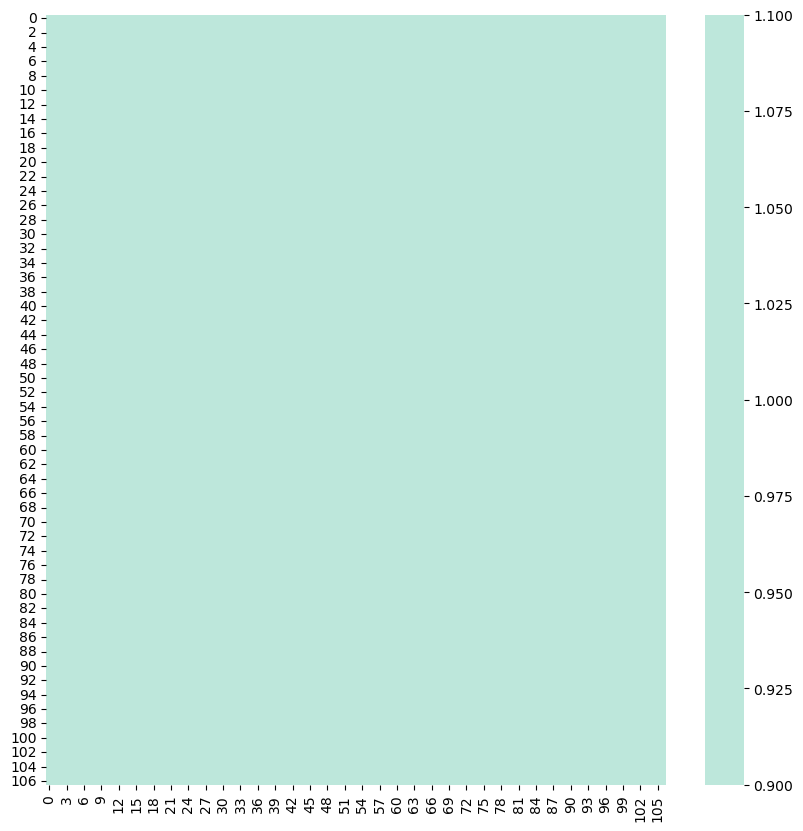

In [19]:
plt.figure(figsize=(10,10))
sns.heatmap(psm_sorted, center=1)
plt.show()

In [20]:
def binder_loss(psm, labels):
    # expected Binder loss from PSM (sum over i<j)
    labels = np.asarray(labels)
    A = (labels[:, None] == labels[None, :]).astype(float)
    iu = np.triu_indices(psm.shape[0], k=1)
    return float(np.sum(np.abs(A[iu] - psm[iu])))

def binder_optimal_partition(psm, k_min, k_max):
    psm = np.asarray(psm, dtype=float)
    psm = 0.5 * (psm + psm.T)
    np.fill_diagonal(psm, 1.0)

    dist = 1.0 - psm
    np.fill_diagonal(dist, 0.0)

    best_loss = np.inf
    best_labels = None

    for k in range(k_min, min(k_max, psm.shape[0]) + 1):
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="average",
            metric="precomputed",  
        )
        labels = model.fit_predict(dist)
        loss = binder_loss(psm, labels)
        if loss < best_loss:
            best_loss = loss
            best_labels = labels

    return best_labels, best_loss

In [21]:
labels_opt, loss_opt = binder_optimal_partition(psm, k_min=1, k_max=5)

In [22]:
loss_opt

0.0

In [23]:
labels_opt

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [24]:
labels = labels_opt + 1

In [25]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

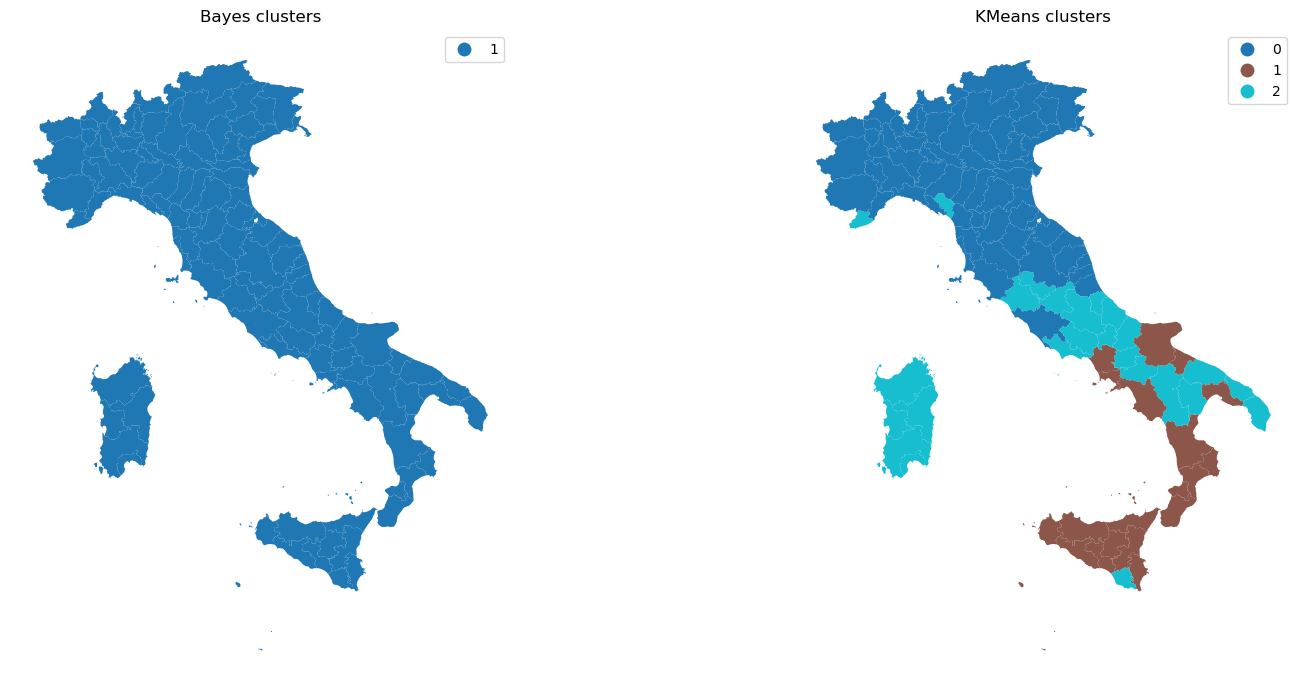

In [26]:
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# gdf: GeoDataFrame with one row per observation/region
# must have a geometry column of polygons/multipolygons
gdf = gpd.read_file("../data/updated_data.geojson")
gdf["cluster_bayes"] = labels

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(y_star.reshape(-1, 1))
gdf["cluster"] = kmeans.labels_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

gdf.plot(column="cluster_bayes", categorical=True, legend=True, ax=ax1)
ax1.set_title("Bayes clusters")
ax1.set_axis_off()

gdf.plot(column="cluster", categorical=True, legend=True, ax=ax2)
ax2.set_title("KMeans clusters")
ax2.set_axis_off()

plt.tight_layout()
plt.show()


In [27]:
with open("labels.txt", "w") as f:
    for x in labels:
        f.write(f"{x}\n")

## "Final" Model

Actually we still have to add in the model the spatial effect

In [28]:
model = """
data {
  int<lower=1> N;                
  int<lower=1> P;                
  int<lower=1> C;                
  array[N] int<lower=1, upper=C> cluster; // cluster label for each observation (1..C)
  matrix[N, P] X;                
  vector[N] y;                   
  vector[N] x_offset; 
}
parameters {
  vector[C] alpha;               // intercept for each cluster
  matrix[C, P] beta;             // coefficient vector (slopes) for each cluster
  vector<lower=1e-6>[C] sigma;      // noise std dev for each cluster
}
model {
  // Priors
  for (c in 1:C) {
    alpha[c] ~ normal(0, 3);
    sigma[c] ~ cauchy(0, 2);
    for (p in 1:P) {
      beta[c, p] ~ normal(0, 3);
    }
  }

                      

  // Likelihood
  for (n in 1:N) {
    int c = cluster[n];
    y[n] ~ normal(alpha[c] + X[n] * beta[c]' + x_offset[n], sigma[c]);
  }
}
"""

In [29]:
with open("labeled_model.stan", "w") as f:
    f.write(model)

In [30]:
data_m = {
    "N": int(N),
    "P": int(P),
    "C": int(K),
    "cluster": labels.astype(int),
    "X": X_star.astype(float),
    "y": y_star.astype(float),
    "x_offset": offset_star.astype(float),
}